# 05 — TensorRT Inference: FP32 / FP16 / INT8 / FP8 / INT4

This notebook runs the full TRT pipeline for each precision mode:
1. Export model to ONNX (skipped if already on disk)
2. Build TensorRT engine (skipped if already on disk)
3. Run evaluation and collect metrics
4. Compare accuracy, latency, and throughput across precisions

**FP8 and INT4** require a QDQ-annotated ONNX from `modelopt` — run `quant_modelopt.py` first.  
**INT8** uses entropy calibration — runner wires the calibrator automatically.

## Setup

In [1]:
import sys
from pathlib import Path

# Make sure src/ is on the path
SRC = Path("..").resolve() / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
import matplotlib.pyplot as plt

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs, print_run_summary
from plots import plot_tradeoff_with_pareto, plot_tradeoff_scatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.3f}".format)

## Base config
All TRT runs share this base. Each precision overrides only `model_precision`.

In [2]:
base = ExperimentConfig(
    backend          = "tensorrt",
    device           = "cuda",
    batch_size       = 1,
    input_quant_bits = 8,
    trt_static_shape = True,
    trt_workspace_mb = 2048,
    num_eval_batches = 500,     # None = full val set
    seed             = 42,
)

## FP32

In [3]:
cfg_fp32 = with_overrides(base, model_precision="fp32")
payload_fp32, tracker_fp32 = run_experiment(cfg_fp32)
print_run_summary(payload_fp32)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp32_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 70.00%  Top-5: 90.00%  Infer: 0.91 ms/batch
  [50/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.90 ms/batch
  [60/500]  Top-1: 80.00%  Top-5: 93.33%  Infer: 0.90 ms/batch
  [70/500]  Top-1: 80.00%  Top-5: 95.00%  Infer: 0.90 ms/batch
  [80/500]  Top-1: 82.00%  Top-5: 94.00%  Infer: 0.91 ms/batch
  [90/500]  Top-1: 81.67%  Top-5: 95.00%  Infer: 0.91 ms/batch
  [100/50

## FP16

In [4]:
cfg_fp16 = with_overrides(base, model_precision="fp16")
payload_fp16, tracker_fp16 = run_experiment(cfg_fp16)
print_run_summary(payload_fp16)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp16_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 70.00%  Top-5: 90.00%  Infer: 0.57 ms/batch
  [50/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.52 ms/batch
  [60/500]  Top-1: 80.00%  Top-5: 93.33%  Infer: 0.54 ms/batch
  [70/500]  Top-1: 80.00%  Top-5: 95.00%  Infer: 0.57 ms/batch
  [80/500]  Top-1: 82.00%  Top-5: 94.00%  Infer: 0.56 ms/batch
  [90/500]  Top-1: 81.67%  Top-5: 95.00%  Infer: 0.55 ms/batch
  [100/50

## INT8
The runner automatically creates an `Int8EntropyCalibrator` from the val set.  
Calibration cache is saved to `engines/<run_id>.calib_cache` and reused on repeated runs.

In [5]:
cfg_int8 = with_overrides(base, model_precision="int8")
payload_int8, tracker_int8 = run_experiment(cfg_int8)
print_run_summary(payload_int8)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 70.00%  Top-5: 90.00%  Infer: 0.84 ms/batch
  [50/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.86 ms/batch
  [60/500]  Top-1: 83.33%  Top-5: 93.33%  Infer: 0.77 ms/batch
  [70/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.75 ms/batch
  [80/500]  Top-1: 86.00%  Top-5: 94.00%  Infer: 0.73 ms/batch
  [90/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.74 ms/batch
  [100/50

## FP8
Requires `onnx/resnet18_fp8_qdq.onnx` — generated by `quant_modelopt.py`.  
No calibrator needed; quantization scales are embedded in the ONNX Q/DQ nodes.

In [6]:
cfg_fp8 = with_overrides(base, model_precision="fp8")
payload_fp8, tracker_fp8 = run_experiment(cfg_fp8)
print_run_summary(payload_fp8)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_fp8_qdq.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_fp8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 70.00%  Top-5: 90.00%  Infer: 0.72 ms/batch
  [50/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.74 ms/batch
  [60/500]  Top-1: 80.00%  Top-5: 93.33%  Infer: 0.71 ms/batch
  [70/500]  Top-1: 80.00%  Top-5: 95.00%  Infer: 0.68 ms/batch
  [80/500]  Top-1: 82.00%  Top-5: 94.00%  Infer: 0.69 ms/batch
  [90/500]  Top-1: 83.33%  Top-5: 95.00%  Infer: 0.68 ms/batch
  [

## INT4 (weights-only)
Requires `onnx/resnet18_int4_qdq.onnx` — generated by `quant_modelopt.py`.  
Weights are quantized to INT4; activations remain FP16.

In [7]:
cfg_int4 = with_overrides(base, model_precision="int4")
payload_int4, tracker_int4 = run_experiment(cfg_int4)
print_run_summary(payload_int4)

[runner] Step 1/3 — ONNX exists, skipping: /home/pf4636/code/resnet/quantized_resnets/onnx/resnet18_int4_qdq.onnx
[runner] Step 2/3 — Engine exists, skipping: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in8b_cuda_bs1.engine
[runner] Step 3/3 — Running TRT inference ...
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/resnet18_tensorrt_int4_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 70.00%  Top-5: 90.00%  Infer: 0.50 ms/batch
  [50/500]  Top-1: 85.00%  Top-5: 95.00%  Infer: 0.54 ms/batch
  [60/500]  Top-1: 76.67%  Top-5: 93.33%  Infer: 0.54 ms/batch
  [70/500]  Top-1: 77.50%  Top-5: 92.50%  Infer: 0.53 ms/batch
  [80/500]  Top-1: 78.00%  Top-5: 92.00%  Infer: 0.54 ms/batch
  [90/500]  Top-1: 78.33%  Top-5: 93.33%  Infer: 0.52 ms/batch


---
## Results

### Summary table

In [8]:
runs = load_runs("../runs")
df   = pd.DataFrame(flatten_runs(runs))

# Keep only TensorRT runs, select the columns that matter
COLS = [
    "cfg.model_precision",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.infer_ms_std",
    "res.throughput_infer_sps",
    "res.total_samples",
]

PRECISION_ORDER = ["fp32", "fp16", "int8", "fp8", "int4"]

df_trt = (
    df[df["cfg.backend"] == "tensorrt"][COLS]
    .drop_duplicates(subset="cfg.model_precision", keep="last")
    .set_index("cfg.model_precision")
    .reindex([p for p in PRECISION_ORDER if p in df["cfg.model_precision"].values])
)

df_trt.columns = ["Top-1 (%)", "Top-5 (%)", "Infer ms (avg)", "Infer ms (std)", "Throughput (sps)", "Samples"]
df_trt

,Top-1 (%),Top-5 (%),Infer ms (avg),Infer ms (std),Throughput (sps),Samples
cfg.model_precision,,,,,,
fp32,78.298,94.255,0.940,0.110,1063.604,470
fp16,78.298,94.255,0.477,0.175,2097.707,470
int8,79.574,94.043,0.709,0.255,1410.877,470
fp8,79.149,94.255,0.641,0.218,1560.170,470
int4,77.872,94.043,0.508,0.190,1969.170,470


In [9]:
df_trt.to_csv("../runs/trt_summary.csv")

### Accuracy drop and speedup vs FP32 baseline

In [10]:
if "fp32" in df_trt.index:
    fp32_top1 = df_trt.loc["fp32", "Top-1 (%)"]
    fp32_ms   = df_trt.loc["fp32", "Infer ms (avg)"]

    summary = df_trt[["Top-1 (%)", "Infer ms (avg)"]].copy()
    summary["ΔTop-1 (pp)"]  = summary["Top-1 (%)"]      - fp32_top1
    summary["Speedup vs FP32"] = fp32_ms / summary["Infer ms (avg)"]
    print(summary.to_string())
else:
    print("FP32 run not found — run cfg_fp32 cell first.")

                     Top-1 (%)  Infer ms (avg)  ΔTop-1 (pp)  Speedup vs FP32
cfg.model_precision                                                         
fp32                    78.298           0.940        0.000            1.000
fp16                    78.298           0.477        0.000            1.972
int8                    79.574           0.709        1.277            1.327
fp8                     79.149           0.641        0.851            1.467
int4                    77.872           0.508       -0.426            1.851


### Accuracy vs Latency (scatter)

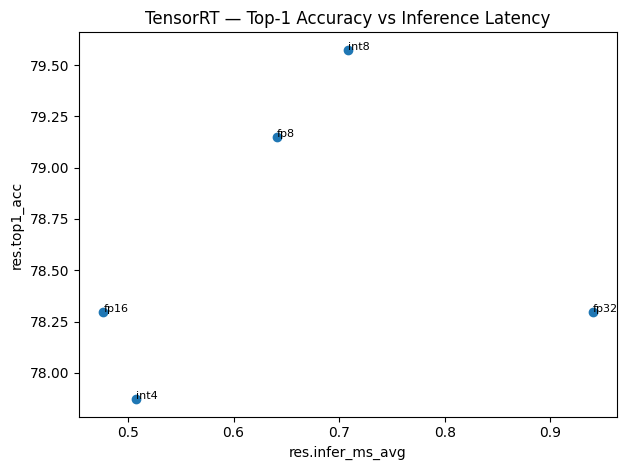

In [11]:
rows_trt = [r for r in flatten_runs(runs) if r.get("cfg.backend") == "tensorrt"]

plot_tradeoff_scatter(
    rows_trt,
    x_key  = "res.infer_ms_avg",
    y_key  = "res.top1_acc",
    label_keys = ("cfg.model_precision",),
    title  = "TensorRT — Top-1 Accuracy vs Inference Latency",
    annotate = True,
)

### Accuracy–Latency Pareto frontier

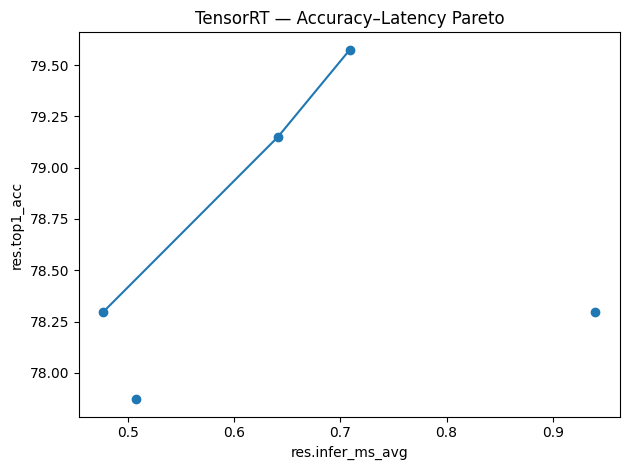

In [12]:
plot_tradeoff_with_pareto(
    rows_trt,
    x_key = "res.infer_ms_avg",
    y_key = "res.top1_acc",
    title = "TensorRT — Accuracy–Latency Pareto",
)

### Throughput bar chart

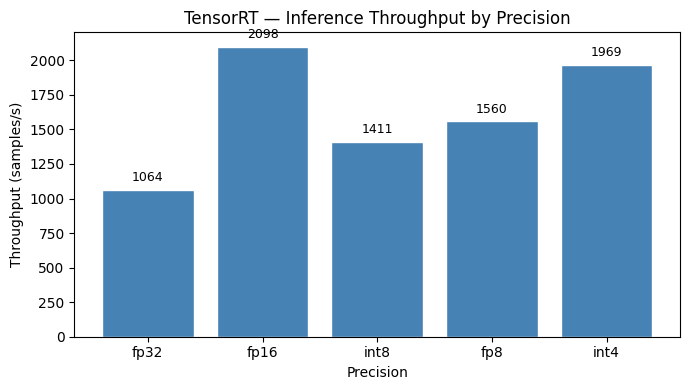

In [13]:
df_plot = df_trt["Throughput (sps)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_plot.index, df_plot.values, color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="{:.0f}", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Throughput (samples/s)")
ax.set_title("TensorRT — Inference Throughput by Precision")
plt.tight_layout()
plt.show()

### Latency bar chart

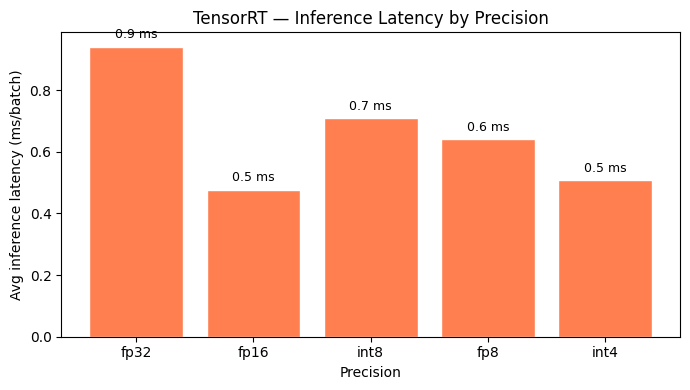

In [14]:
df_lat = df_trt["Infer ms (avg)"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_lat.index, df_lat.values, color="coral", edgecolor="white")
ax.bar_label(bars, fmt="{:.1f} ms", padding=4, fontsize=9)
ax.set_xlabel("Precision")
ax.set_ylabel("Avg inference latency (ms/batch)")
ax.set_title("TensorRT — Inference Latency by Precision")
plt.tight_layout()
plt.show()